In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd 

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [4]:

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [5]:
print(train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [11]:
pd.crosstab(train['Sex'], train['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [12]:
pd.crosstab(train['Sex'],['Survived'], normalize='index')

col_0,Survived
Sex,
female,1.0
male,1.0


In [13]:
pd.crosstab(
    train['Sex'],
    train['Survived'],
    normalize='index'
).round(3)

Survived,0,1
Sex,,
female,0.258,0.742
male,0.811,0.189


In [14]:
pd.crosstab(train['Pclass'],train['Survived'],normalize='index').round(3)

Survived,0,1
Pclass,,
1,0.370,0.630
2,0.527,0.473
3,0.758,0.242


In [15]:
pd.crosstab(
    [train['Pclass'], train['Sex']],
    train['Survived'],
    normalize='index'
).round(3)

Survived           0      1
Pclass Sex                 
1      female  0.032  0.968
       male    0.631  0.369
2      female  0.079  0.921
       male    0.843  0.157
3      female  0.500  0.500
       male    0.865  0.135

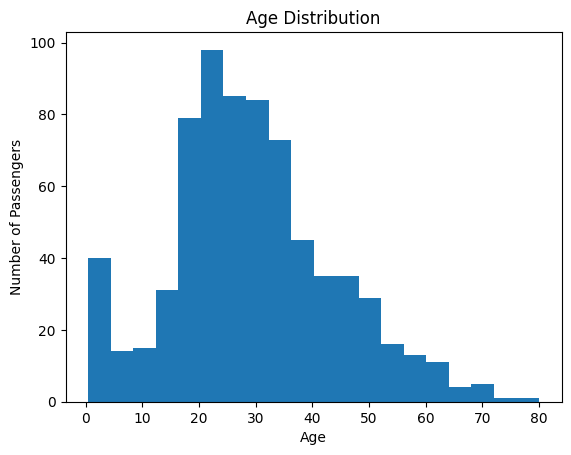

In [16]:
import matplotlib.pyplot as plt

plt.hist(train['Age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution')
plt.show()

In [17]:
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [18]:
train['Age'].skew()

np.float64(0.38910778230082704)

In [19]:
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=[0, 12, 18, 35, 60, 80],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

In [20]:
pd.crosstab(
    train['AgeGroup'],
    train['Survived'],
    normalize='index'
).round(3)

Survived,0,1
AgeGroup,,
Child,0.420,0.580
Teen,0.571,0.429
Young Adult,0.617,0.383
Adult,0.600,0.400
Senior,0.773,0.227


In [21]:
train[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,NaN,NaN
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teen


In [22]:
train['Cabin'].notna().value_counts()

Cabin
False    687
True     204
Name: count, dtype: int64

In [23]:
pd.crosstab(
    train['Cabin'].notna(),
    train['Survived'],
    normalize='index'
).round(3)

Survived,0,1
Cabin,,
False,0.700,0.300
True,0.333,0.667


In [24]:
train['HasCabin'] = train['Cabin'].notna().astype(int)

In [25]:
train[['Cabin', 'HasCabin']].head(10)

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


In [26]:
train['Embarked'] = train['Embarked'].fillna('S')

In [27]:
train['Embarked'].isna().sum()

np.int64(0)

In [28]:
train['Title'] = train['Name'].str.extract(r',\s*([^.]*)\.')

In [29]:
train[['Name', 'Title']].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [30]:
train['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [31]:
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']

train['Title'] = train['Title'].where(
    train['Title'].isin(common_titles),
    'Rare'
)

In [32]:
train['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [33]:
pd.get_dummies(train['Title'], dtype=int)

,Master,Miss,Mr,Mrs,Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0
...,...,...,...,...,...
886,0,0,0,0,1
887,0,1,0,0,0
888,0,1,0,0,0
889,0,0,1,0,0


In [34]:
title_dummies = pd.get_dummies(train['Title'], dtype=int)

train = pd.concat(
    [train, title_dummies],
    axis=1
)

In [35]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,HasCabin,Title,Master,Miss,Mr,Mrs,Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult,0,Mr,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,1,Mrs,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult,0,Miss,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young Adult,1,Mrs,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young Adult,0,Mr,0,0,1,0,0


In [36]:
train.shape

(891, 20)

In [37]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup', 'HasCabin',
       'Title', 'Master', 'Miss', 'Mr', 'Mrs', 'Rare'],
      dtype='object')

In [38]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeGroup       177
HasCabin         0
Title            0
Master           0
Miss             0
Mr               0
Mrs              0
Rare             0
dtype: int64

In [39]:
train.groupby('Survived')['Age'].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [40]:
train['Age'].median()

28.0

In [41]:
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [42]:
train.drop(columns=['AgeGroup'], inplace=True)

In [43]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'HasCabin', 'Title',
       'Master', 'Miss', 'Mr', 'Mrs', 'Rare'],
      dtype='object')

In [44]:
train.drop(columns=['Title'], inplace=True)

In [45]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'HasCabin', 'Master',
       'Miss', 'Mr', 'Mrs', 'Rare'],
      dtype='object')

In [46]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1}); print(train['Sex'].value_counts())

Sex
0    577
1    314
Name: count, dtype: int64


In [47]:
embarked_dummies = pd.get_dummies(train['Embarked'], prefix='Embarked', dtype=int); train = pd.concat([train, embarked_dummies], axis=1); print(train[['Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head())

  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        S           0           0           1
1        C           1           0           0
2        S           0           0           1
3        S           0           0           1
4        S           0           0           1


In [48]:
train.drop(columns=['Embarked'], inplace=True); print(train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'HasCabin', 'Master', 'Miss', 'Mr',
       'Mrs', 'Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [49]:
print('Missing Age:', train['Age'].isna().sum(), '| Median Age:', train['Age'].median())

Missing Age: 177 | Median Age: 28.0


In [50]:
train['Age'] = train['Age'].fillna(train['Age'].median()); print('Missing Age:', train['Age'].isna().sum(), '| Median used:', train['Age'].median())

Missing Age: 0 | Median used: 28.0


In [51]:
train.drop(columns=['PassengerId'], inplace=True); print(train.columns.tolist())

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'HasCabin', 'Master', 'Miss', 'Mr', 'Mrs', 'Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [52]:
print('Unique Tickets:', train['Ticket'].nunique(), '| Total:', len(train), '| Duplicate Tickets:', train['Ticket'].duplicated().sum())

Unique Tickets: 681 | Total: 891 | Duplicate Tickets: 210


In [53]:
train['TicketGroupSize'] = train.groupby('Ticket')['Ticket'].transform('count'); print(train['TicketGroupSize'].value_counts().sort_index())

TicketGroupSize
1    547
2    188
3     63
4     44
5     10
6     18
7     21
Name: count, dtype: int64


In [54]:
print(pd.crosstab(train['TicketGroupSize'], train['Survived'], normalize='index').round(3))

Survived             0      1
TicketGroupSize              
1                0.702  0.298
2                0.426  0.574
3                0.302  0.698
4                0.500  0.500
5                1.000  0.000
6                1.000  0.000
7                0.762  0.238


In [55]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1; print(train['FamilySize'].value_counts().sort_index())

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [56]:
print(pd.crosstab(train['FamilySize'], train['Survived'], normalize='index').round(3))

Survived        0      1
FamilySize              
1           0.696  0.304
2           0.447  0.553
3           0.422  0.578
4           0.276  0.724
5           0.800  0.200
6           0.864  0.136
7           0.667  0.333
8           1.000  0.000
11          1.000  0.000


In [57]:
print(train['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [58]:
print(train.loc[train['Fare'] > 100, ['Pclass','Sex','Age','Fare','Survived']].sort_values('Fare', ascending=False).head(15))

     Pclass  Sex   Age      Fare  Survived
258       1    1  35.0  512.3292         1
679       1    0  36.0  512.3292         1
737       1    0  35.0  512.3292         1
88        1    1  23.0  263.0000         1
27        1    0  19.0  263.0000         0
438       1    0  64.0  263.0000         0
341       1    1  24.0  263.0000         1
311       1    1  18.0  262.3750         1
742       1    1  21.0  262.3750         1
299       1    1  50.0  247.5208         1
118       1    0  24.0  247.5208         0
700       1    1  18.0  227.5250         1
380       1    1  42.0  227.5250         1
557       1    0  28.0  227.5250         0
716       1    1  38.0  227.5250         1


In [59]:
print(train.loc[train['Fare'] == 0, ['Pclass','Sex','Age','Fare','Ticket','Survived']])

     Pclass  Sex   Age  Fare  Ticket  Survived
179       3    0  36.0   0.0    LINE         0
263       1    0  40.0   0.0  112059         0
271       3    0  25.0   0.0    LINE         1
277       2    0  28.0   0.0  239853         0
302       3    0  19.0   0.0    LINE         0
413       2    0  28.0   0.0  239853         0
466       2    0  28.0   0.0  239853         0
481       2    0  28.0   0.0  239854         0
597       3    0  49.0   0.0    LINE         0
633       1    0  28.0   0.0  112052         0
674       2    0  28.0   0.0  239856         0
732       2    0  28.0   0.0  239855         0
806       1    0  39.0   0.0  112050         0
815       1    0  28.0   0.0  112058         0
822       1    0  38.0   0.0   19972         0


In [60]:
train.drop(columns=['Cabin'], inplace=True); print(train.columns.tolist())

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'HasCabin', 'Master', 'Miss', 'Mr', 'Mrs', 'Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'TicketGroupSize', 'FamilySize']


In [61]:
train.drop(columns=['Name', 'Ticket'], inplace=True); print(train.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Master', 'Miss', 'Mr', 'Mrs', 'Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'TicketGroupSize', 'FamilySize']


In [62]:
print('Total Missing:', train.isna().sum().sum()); print(train.isna().sum()[train.isna().sum() > 0])

Total Missing: 0
Series([], dtype: int64)


In [63]:
X = train.drop(columns=['Survived']); y = train['Survived']; print('X:', X.shape, '| y:', y.shape); print('Target:', y.value_counts().to_dict())

X: (891, 17) | y: (891,)
Target: {0: 549, 1: 342}


In [64]:
from sklearn.model_selection import train_test_split; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y); print('X_train:', X_train.shape, '| X_test:', X_test.shape, '| y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (712, 17) | X_test: (179, 17) | y_train: (712,) | y_test: (179,)


In [65]:
from sklearn.preprocessing import StandardScaler; scaler = StandardScaler(); X_train_scaled = scaler.fit_transform(X_train); X_test_scaled = scaler.transform(X_test); print('X_train_scaled:', X_train_scaled.shape, '| X_test_scaled:', X_test_scaled.shape)

X_train_scaled: (712, 17) | X_test_scaled: (179, 17)


In [66]:
from sklearn.linear_model import LogisticRegression; model_lr = LogisticRegression(max_iter=1000, random_state=42); model_lr.fit(X_train_scaled, y_train); y_pred_lr = model_lr.predict(X_test_scaled); print('Logistic Regression Accuracy:', round(model_lr.score(X_test_scaled, y_test), 3))

Logistic Regression Accuracy: 0.844


In [67]:
from sklearn.metrics import confusion_matrix; cm = confusion_matrix(y_test, y_pred_lr); print(cm)

[[96 14]
 [14 55]]


In [68]:
from sklearn.metrics import classification_report; print(classification_report(y_test, y_pred_lr, target_names=['Died','Survived']))

              precision    recall  f1-score   support

        Died       0.87      0.87      0.87       110
    Survived       0.80      0.80      0.80        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [69]:
from sklearn.ensemble import RandomForestClassifier; model_rf = RandomForestClassifier(n_estimators=100, random_state=42); model_rf.fit(X_train, y_train); y_pred_rf = model_rf.predict(X_test); print('Random Forest Accuracy:', round(model_rf.score(X_test, y_test), 3))

Random Forest Accuracy: 0.793


In [70]:
print('Random Forest Train Accuracy:', round(model_rf.score(X_train, y_train), 3), '| Test Accuracy:', round(model_rf.score(X_test, y_test), 3))

Random Forest Train Accuracy: 0.985 | Test Accuracy: 0.793


In [71]:
for depth in [3, 5, 7, 10]: model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42); model.fit(X_train, y_train); print(f'max_depth={depth} | Train={model.score(X_train,y_train):.3f} | Test={model.score(X_test,y_test):.3f}')

max_depth=3 | Train=0.838 | Test=0.799
max_depth=5 | Train=0.855 | Test=0.816
max_depth=7 | Train=0.907 | Test=0.799
max_depth=10 | Train=0.948 | Test=0.788


In [72]:
model_rf5 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42); model_rf5.fit(X_train, y_train); y_pred_rf5 = model_rf5.predict(X_test); from sklearn.metrics import accuracy_score, classification_report; print('Accuracy:', round(accuracy_score(y_test, y_pred_rf5), 3)); print(classification_report(y_test, y_pred_rf5, target_names=['Died','Survived']))

Accuracy: 0.816
              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       110
    Survived       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [73]:
from sklearn.model_selection import cross_val_score; cv_scores = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring='accuracy'); print('CV Scores:', cv_scores.round(3)); print('Mean CV Accuracy:', round(cv_scores.mean(), 3))

CV Scores: [0.797 0.818 0.831 0.831 0.817]
Mean CV Accuracy: 0.819


In [74]:
cv_rf_scores = cross_val_score(model_rf5, X_train, y_train, cv=5, scoring='accuracy'); print('RF CV Scores:', cv_rf_scores.round(3)); print('RF Mean CV Accuracy:', round(cv_rf_scores.mean(), 3))

RF CV Scores: [0.832 0.79  0.852 0.838 0.817]
RF Mean CV Accuracy: 0.826


In [75]:
from sklearn.model_selection import GridSearchCV; param_grid={'n_estimators':[100,200],'max_depth':[3,5,7],'min_samples_split':[2,5,10]}; grid_search=GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring='accuracy',n_jobs=-1); grid_search.fit(X_train,y_train); print('Best Parameters:',grid_search.best_params_); print('Best CV Accuracy:',round(grid_search.best_score_,3))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.827


In [76]:
best_rf = grid_search.best_estimator_; y_pred_best_rf = best_rf.predict(X_test); from sklearn.metrics import accuracy_score, classification_report; print('Final Test Accuracy:', round(accuracy_score(y_test, y_pred_best_rf), 3)); print(classification_report(y_test, y_pred_best_rf, target_names=['Died','Survived']))

Final Test Accuracy: 0.804
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [77]:
import pandas as pd; coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_lr.coef_[0]}).sort_values('Coefficient', ascending=False); print(coef_df.to_string(index=False))

        Feature  Coefficient
            Sex     1.082648
         Master     0.462813
       HasCabin     0.397441
            Mrs     0.251715
           Fare     0.106676
     Embarked_Q     0.104327
TicketGroupSize     0.058595
     Embarked_C     0.048659
           Rare     0.009835
           Miss    -0.052774
     Embarked_S    -0.105879
          Parch    -0.138249
     FamilySize    -0.282612
          SibSp    -0.314138
             Mr    -0.334215
            Age    -0.393534
         Pclass    -0.618728


In [78]:
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_}).sort_values('Importance', ascending=False); print(importance_df.to_string(index=False))

        Feature  Importance
            Sex    0.244403
             Mr    0.191088
           Fare    0.097449
         Pclass    0.075587
            Age    0.063921
       HasCabin    0.059641
TicketGroupSize    0.053746
            Mrs    0.050515
           Miss    0.045654
     FamilySize    0.043223
          SibSp    0.020218
          Parch    0.014000
     Embarked_S    0.011683
     Embarked_C    0.008084
     Embarked_Q    0.007479
         Master    0.007159
           Rare    0.006149


In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score; print(pd.DataFrame({'Metric':['Accuracy','Precision','Recall','F1'], 'Logistic Regression':[accuracy_score(y_test,y_pred_lr),precision_score(y_test,y_pred_lr),recall_score(y_test,y_pred_lr),f1_score(y_test,y_pred_lr)], 'Random Forest':[accuracy_score(y_test,y_pred_best_rf),precision_score(y_test,y_pred_best_rf),recall_score(y_test,y_pred_best_rf),f1_score(y_test,y_pred_best_rf)]}).round(3).to_string(index=False))

   Metric  Logistic Regression  Random Forest
 Accuracy                0.844          0.804
Precision                0.797          0.766
   Recall                0.797          0.710
       F1                0.797          0.737


In [80]:
import joblib; joblib.dump(model_lr, 'titanic_logistic_model.pkl'); joblib.dump(scaler, 'titanic_scaler.pkl'); print('Model and Scaler saved successfully!')

Model and Scaler saved successfully!


In [81]:
feature_names = list(X.columns); joblib.dump(feature_names, 'titanic_feature_names.pkl'); print('Feature names saved:', len(feature_names), '| First 5:', feature_names[:5])

Feature names saved: 17 | First 5: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']


In [82]:
print('train:', train.shape, '| test:', test.shape)

train: (891, 18) | test: (418, 11)


In [83]:
test['Title'] = test['Name'].str.extract(r',\s*([^.]*)\.')[0].str.strip(); test['Title'] = test['Title'].replace(['Dr','Rev','Col','Major','Mlle','Ms','Mme','Don','Lady','Sir','Capt','the Countess','Jonkheer'],'Rare'); print(test['Title'].value_counts())

Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        6
Dona        1
Name: count, dtype: int64


In [84]:
test['Title'] = test['Title'].replace('Dona','Rare'); print(test['Title'].value_counts())

Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        7
Name: count, dtype: int64


In [85]:
test['HasCabin'] = test['Cabin'].notna().astype(int); print(test['HasCabin'].value_counts())

HasCabin
0    327
1     91
Name: count, dtype: int64


In [86]:
age_median=train['Age'].median(); test['Age']=test['Age'].fillna(age_median); print('Missing Age:',test['Age'].isna().sum(),'| Median from train:',age_median)

Missing Age: 0 | Median from train: 28.0


In [87]:
title_dummies = pd.get_dummies(test['Title'], prefix='', prefix_sep='').reindex(columns=['Master','Miss','Mr','Mrs','Rare'], fill_value=0).astype(int); test = pd.concat([test, title_dummies], axis=1); print(test[['Title','Master','Miss','Mr','Mrs','Rare']].head())

  Title  Master  Miss  Mr  Mrs  Rare
0    Mr       0     0   1    0     0
1   Mrs       0     0   0    1     0
2    Mr       0     0   1    0     0
3    Mr       0     0   1    0     0
4   Mrs       0     0   0    1     0


In [88]:
embarked_dummies=pd.get_dummies(test['Embarked'],prefix='Embarked').reindex(columns=['Embarked_C','Embarked_Q','Embarked_S'],fill_value=0).astype(int); test=pd.concat([test,embarked_dummies],axis=1); print(test[['Embarked','Embarked_C','Embarked_Q','Embarked_S']].head())

  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        Q           0           1           0
1        S           0           0           1
2        Q           0           1           0
3        S           0           0           1
4        S           0           0           1


In [89]:
test['TicketGroupSize']=test.groupby('Ticket')['Ticket'].transform('count'); test['FamilySize']=test['SibSp']+test['Parch']+1; print(test[['Ticket','TicketGroupSize','SibSp','Parch','FamilySize']].head(10))

      Ticket  TicketGroupSize  SibSp  Parch  FamilySize
0     330911                1      0      0           1
1     363272                1      1      0           2
2     240276                1      0      0           1
3     315154                1      0      0           1
4    3101298                1      1      1           3
5       7538                1      0      0           1
6     330972                1      0      0           1
7     248738                1      1      1           3
8       2657                1      0      0           1
9  A/4 48871                1      2      0           3


In [90]:
features=list(X.columns); X_test_final=test[features].copy(); print('X_test_final:',X_test_final.shape); print(X_test_final.columns.tolist())

X_test_final: (418, 17)
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Master', 'Miss', 'Mr', 'Mrs', 'Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'TicketGroupSize', 'FamilySize']


In [91]:
test['Sex']=test['Sex'].map({'male':0,'female':1}); X_test_final=test[X.columns].copy(); X_test_final_scaled=scaler.transform(X_test_final); print('Sex:',test['Sex'].value_counts().to_dict(),'| Scaled:',X_test_final_scaled.shape)

Sex: {0: 266, 1: 152} | Scaled: (418, 17)


In [92]:
print(X_test_final.isna().sum()[X_test_final.isna().sum()>0])

Fare    1
dtype: int64


In [93]:
fare_median=train['Fare'].median(); X_test_final['Fare']=X_test_final['Fare'].fillna(fare_median); X_test_final_scaled=scaler.transform(X_test_final); print('Missing Fare:',X_test_final['Fare'].isna().sum(),'| Fare median from train:',fare_median,'| Scaled:',X_test_final_scaled.shape)

Missing Fare: 0 | Fare median from train: 14.4542 | Scaled: (418, 17)


In [94]:
test_predictions=model_lr.predict(X_test_final_scaled); print('Predictions:',len(test_predictions),'| Survived:',test_predictions.sum(),'| Died:',(test_predictions==0).sum())

Predictions: 418 | Survived: 169 | Died: 249


In [95]:
submission=pd.DataFrame({'PassengerId':test['PassengerId'],'Survived':test_predictions}); submission.to_csv('submission.csv',index=False); print(submission.head()); print('Submission shape:',submission.shape); print('File saved: submission.csv')

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
Submission shape: (418, 2)
File saved: submission.csv
